In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

# 데이터 로드
summary = pd.read_csv('/content/drive/MyDrive/취업 포폴/Olist 비즈니스 데이터 분석/olist_churn_segment.csv')

customers = pd.read_csv('/content/drive/MyDrive/취업 포폴/Olist 비즈니스 데이터 분석/olist data/olist_customers_dataset.csv')
orders = pd.read_csv('/content/drive/MyDrive/취업 포폴/Olist 비즈니스 데이터 분석/olist data/olist_orders_dataset.csv')
order_items = pd.read_csv('/content/drive/MyDrive/취업 포폴/Olist 비즈니스 데이터 분석/olist data/olist_order_items_dataset.csv')
products = pd.read_csv('/content/drive/MyDrive/취업 포폴/Olist 비즈니스 데이터 분석/olist data/olist_products_dataset.csv')
reviews = pd.read_csv('/content/drive/MyDrive/취업 포폴/Olist 비즈니스 데이터 분석/olist data/olist_order_reviews_dataset.csv')

# 분석용 데이터 마트 생성

In [3]:
# customer_unique_id 붙이기
orders = orders.merge(
    customers[['customer_id', 'customer_unique_id']],
    on='customer_id',
    how='left'
)

In [4]:
summary['customer_id'] = summary['customer_id'].astype(str)
orders['customer_unique_id'] = orders['customer_unique_id'].astype(str)

In [5]:
# 분석용 데이터 마트 생성
# order_items + product
item_df = order_items.merge(products, on='product_id', how='left')

# 카테고리
cat_df = item_df.groupby('order_id')['product_category_name'].first().reset_index()

# 리뷰
review_df = reviews.groupby('order_id')['review_score'].mean().reset_index()

# orders + feature 결합
order_df = orders.merge(cat_df, on='order_id', how='left')
order_df = order_df.merge(review_df, on='order_id', how='left')

# 배송 지연 여부
order_df['order_delivered_customer_date'] = pd.to_datetime(order_df['order_delivered_customer_date'])
order_df['order_estimated_delivery_date'] = pd.to_datetime(order_df['order_estimated_delivery_date'])

order_df['is_delayed'] = (
    order_df['order_delivered_customer_date'] > order_df['order_estimated_delivery_date']
).astype(int)

In [6]:
print(order_df.columns)

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'product_category_name', 'review_score',
       'is_delayed'],
      dtype='object')


In [7]:
# 1. 컬럼 존재 확인
print(order_df.columns)

# 2. null 확인
print(order_df[['order_delivered_customer_date', 'order_estimated_delivery_date']].isna().mean())

# 3. 샘플 확인
order_df[['order_delivered_customer_date', 'order_estimated_delivery_date']].head()

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'product_category_name', 'review_score',
       'is_delayed'],
      dtype='object')
order_delivered_customer_date    0.029817
order_estimated_delivery_date    0.000000
dtype: float64


,order_delivered_customer_date,order_estimated_delivery_date
0,2017-10-10 21:25:13,2017-10-18
1,2018-08-07 15:27:45,2018-08-13
2,2018-08-17 18:06:29,2018-09-04
3,2017-12-02 00:28:42,2017-12-15
4,2018-02-16 18:17:02,2018-02-26


In [8]:
#summary와 결합
df = summary.merge(
    order_df,
    left_on='customer_id',
    right_on='customer_unique_id',
    how='left'
)

In [9]:
print(df.shape)
print(df['order_id'].isna().mean())  # 0.1 이하 정상

(96683, 27)
0.0


In [11]:
df['churn_type'] = df['churn_type'].fillna('Non-churn')


In [12]:
df['churn_type'].value_counts(dropna=False)
# df['churn_type'].unique()
# df['churn_type'].isna().sum()

,count
churn_type,
Early,67015
Non-churn,25941
Loyal,3727


In [ ]:
# #Early churn 데이터 분리
# early_df = df[df['churn_type'] == 'Early']
# non_early_df = df[df['churn_type'] == 'Others']

In [13]:
df.columns

Index(['customer_id_x', 'first_order', 'last_order', 'order_count',
       'avg_order_gap', 'reference_date', 'days_since_last', 'churn_90',
       'churn_dynamic', 'total_revenue', 'median_order_gap', 'lifecycle',
       'churn_type', 'behavior', 'value_segment', 'order_id', 'customer_id_y',
       'order_status', 'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_unique_id',
       'product_category_name', 'review_score', 'is_delayed'],
      dtype='object')

In [14]:
df.to_csv('analysis_df.csv', index=False)

In [15]:
df.head(20)

,customer_id_x,first_order,last_order,order_count,avg_order_gap,reference_date,days_since_last,churn_90,churn_dynamic,total_revenue,...,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,product_category_name,review_score,is_delayed
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,2018-05-10 10:56:27,1,NaN,2018-10-30,173,1,0,141.90,...,delivered,2018-05-10 10:56:27,2018-05-10 11:11:18,2018-05-12 08:18:00,2018-05-16 20:48:37,2018-05-21,0000366f3b9a7992bf8c76cfdf3221e2,cama_mesa_banho,5.0,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,2018-05-07 11:11:27,1,NaN,2018-10-30,176,1,0,27.19,...,delivered,2018-05-07 11:11:27,2018-05-07 18:25:44,2018-05-09 12:18:00,2018-05-10 18:02:42,2018-05-15,0000b849f77a49e4a4ce2b2a4ca5be3f,beleza_saude,4.0,0
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,2017-03-10 21:05:03,1,NaN,2018-10-30,599,1,0,86.22,...,delivered,2017-03-10 21:05:03,2017-03-10 21:05:03,2017-03-13 12:58:30,2017-04-05 14:38:47,2017-04-07,0000f46a3911fa3c0805444483337064,papelaria,3.0,0
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,2017-10-12 20:29:41,1,NaN,2018-10-30,383,1,0,43.62,...,delivered,2017-10-12 20:29:41,2017-10-12 20:49:17,2017-10-13 20:08:19,2017-11-01 21:23:05,2017-11-13,0000f6ccb0745a6a4b88665a16c9f078,telefonia,4.0,0
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,2017-11-14 19:45:42,1,NaN,2018-10-30,350,1,0,196.89,...,delivered,2017-11-14 19:45:42,2017-11-14 20:06:52,2017-11-16 19:52:10,2017-11-27 23:08:56,2017-12-05,0004aac84e0df4da2b147fca70cf8255,telefonia,5.0,0
5,0004bd2a26a76fe21f786e4fbd80607f,2018-04-05 19:33:16,2018-04-05 19:33:16,1,NaN,2018-10-30,208,1,0,166.98,...,delivered,2018-04-05 19:33:16,2018-04-05 19:48:59,2018-04-07 00:38:52,2018-04-07 16:12:43,2018-04-19,0004bd2a26a76fe21f786e4fbd80607f,ferramentas_jardim,4.0,0
6,00050ab1314c0e55a6ca13cf7181fecf,2018-04-20 12:57:23,2018-04-20 12:57:23,1,NaN,2018-10-30,193,1,0,35.38,...,delivered,2018-04-20 12:57:23,2018-04-25 03:51:13,2018-04-25 15:25:00,2018-04-27 12:08:59,2018-05-09,00050ab1314c0e55a6ca13cf7181fecf,telefonia,4.0,0
7,00053a61a98854899e70ed204dd4bafe,2018-02-28 11:15:41,2018-02-28 11:15:41,1,NaN,2018-10-30,244,1,0,419.18,...,delivered,2018-02-28 11:15:41,2018-02-28 11:32:42,2018-03-01 20:09:30,2018-03-16 19:02:51,2018-03-26,00053a61a98854899e70ed204dd4bafe,esporte_lazer,1.0,0
8,0005e1862207bf6ccc02e4228effd9a0,2017-03-04 23:32:12,2017-03-04 23:32:12,1,NaN,2018-10-30,605,1,0,150.12,...,delivered,2017-03-04 23:32:12,2017-03-04 23:43:26,2017-03-06 05:14:07,2017-03-09 08:33:08,2017-04-06,0005e1862207bf6ccc02e4228effd9a0,fashion_bolsas_e_acessorios,4.0,0
9,0005ef4cd20d2893f0d9fbd94d3c0d97,2018-03-12 15:22:12,2018-03-12 15:22:12,1,NaN,2018-10-30,232,1,0,129.76,...,delivered,2018-03-12 15:22:12,2018-03-12 15:38:46,2018-03-13 16:07:27,2018-05-05 12:38:38,2018-04-04,0005ef4cd20d2893f0d9fbd94d3c0d97,esporte_lazer,1.0,1


# 첫 구매 카테고리 분석

In [16]:
import pandas as pd
df = summary = pd.read_csv('/content/drive/MyDrive/취업 포폴/Olist 비즈니스 데이터 분석/analysis_df.csv')
df

,customer_id_x,first_order,last_order,order_count,avg_order_gap,reference_date,days_since_last,churn_90,churn_dynamic,total_revenue,...,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,product_category_name,review_score,is_delayed
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,2018-05-10 10:56:27,1,NaN,2018-10-30,173,1,0,141.90,...,delivered,2018-05-10 10:56:27,2018-05-10 11:11:18,2018-05-12 08:18:00,2018-05-16 20:48:37,2018-05-21,0000366f3b9a7992bf8c76cfdf3221e2,cama_mesa_banho,5.0,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,2018-05-07 11:11:27,1,NaN,2018-10-30,176,1,0,27.19,...,delivered,2018-05-07 11:11:27,2018-05-07 18:25:44,2018-05-09 12:18:00,2018-05-10 18:02:42,2018-05-15,0000b849f77a49e4a4ce2b2a4ca5be3f,beleza_saude,4.0,0
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,2017-03-10 21:05:03,1,NaN,2018-10-30,599,1,0,86.22,...,delivered,2017-03-10 21:05:03,2017-03-10 21:05:03,2017-03-13 12:58:30,2017-04-05 14:38:47,2017-04-07,0000f46a3911fa3c0805444483337064,papelaria,3.0,0
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,2017-10-12 20:29:41,1,NaN,2018-10-30,383,1,0,43.62,...,delivered,2017-10-12 20:29:41,2017-10-12 20:49:17,2017-10-13 20:08:19,2017-11-01 21:23:05,2017-11-13,0000f6ccb0745a6a4b88665a16c9f078,telefonia,4.0,0
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,2017-11-14 19:45:42,1,NaN,2018-10-30,350,1,0,196.89,...,delivered,2017-11-14 19:45:42,2017-11-14 20:06:52,2017-11-16 19:52:10,2017-11-27 23:08:56,2017-12-05,0004aac84e0df4da2b147fca70cf8255,telefonia,5.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96678,fffcf5a5ff07b0908bd4e2dbc735a684,2017-06-08 21:00:36,2017-06-08 21:00:36,1,NaN,2018-10-30,509,1,0,2067.42,...,delivered,2017-06-08 21:00:36,2017-06-08 21:15:16,2017-06-23 13:03:27,2017-07-06 09:22:00,2017-08-02,fffcf5a5ff07b0908bd4e2dbc735a684,beleza_saude,5.0,0
96679,fffea47cd6d3cc0a88bd621562a9d061,2017-12-10 20:07:56,2017-12-10 20:07:56,1,NaN,2018-10-30,324,1,0,84.58,...,delivered,2017-12-10 20:07:56,2017-12-10 20:16:20,2017-12-21 16:27:01,2018-01-09 22:28:20,2018-01-12,fffea47cd6d3cc0a88bd621562a9d061,bebes,4.0,0
96680,ffff371b4d645b6ecea244b27531430a,2017-02-07 15:49:16,2017-02-07 15:49:16,1,NaN,2018-10-30,630,1,0,112.46,...,delivered,2017-02-07 15:49:16,2017-02-07 16:02:44,2017-02-08 10:04:37,2017-02-22 12:45:04,2017-03-24,ffff371b4d645b6ecea244b27531430a,automotivo,5.0,0
96681,ffff5962728ec6157033ef9805bacc48,2018-05-02 15:17:41,2018-05-02 15:17:41,1,NaN,2018-10-30,181,1,0,133.69,...,delivered,2018-05-02 15:17:41,2018-05-02 15:58:47,2018-05-03 16:45:00,2018-05-14 11:54:26,2018-05-28,ffff5962728ec6157033ef9805bacc48,relogios_presentes,5.0,0


In [17]:
cat_churn = (
    df.groupby(['product_category_name', 'churn_type'])['customer_unique_id']
    .count()
    .unstack()
)

cat_churn['churn_rate'] = cat_churn['Early'] / (cat_churn['Loyal'] + cat_churn['Non-churn']+ cat_churn['Early'])
cat_churn = cat_churn.sort_values('churn_rate', ascending=False)

cat_churn

churn_type,Early,Loyal,Non-churn,churn_rate
product_category_name,,,,
tablets_impressao_imagem,71.0,4.0,2.0,0.922078
moveis_colchao_e_estofado,32.0,3.0,2.0,0.864865
fashion_underwear_e_moda_praia,101.0,6.0,10.0,0.863248
market_place,228.0,9.0,32.0,0.847584
fashion_roupa_feminina,31.0,2.0,4.0,0.837838
...,...,...,...,...
fashion_esporte,22.0,NaN,2.0,NaN
flores,26.0,NaN,3.0,NaN
pc_gamer,4.0,NaN,2.0,NaN


# 첫 구매 금액 vs 이탈 (t-test)

In [18]:
early_df = df[df['churn_type'] == 'Early']
non_early_df = df[df['churn_type'] != 'Early']

In [19]:
from scipy.stats import ttest_ind

early_rev = early_df['total_revenue'].dropna()
non_early_rev = non_early_df['total_revenue'].dropna()

t_stat, p_val = ttest_ind(early_rev, non_early_rev, equal_var=False)

print("t-stat:", t_stat)
print("p-value:", p_val)

t-stat: -20.76614849242114
p-value: 2.3949827914153313e-95


# 리뷰 점수 vs 이탈

In [20]:
df.columns

Index(['customer_id_x', 'first_order', 'last_order', 'order_count',
       'avg_order_gap', 'reference_date', 'days_since_last', 'churn_90',
       'churn_dynamic', 'total_revenue', 'median_order_gap', 'lifecycle',
       'churn_type', 'behavior', 'value_segment', 'order_id', 'customer_id_y',
       'order_status', 'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_unique_id',
       'product_category_name', 'review_score', 'is_delayed'],
      dtype='object')

In [21]:
# 리뷰 점수 이탈에 영향이 있는지
import numpy as np
from scipy.stats import chi2_contingency

df['review_group'] = np.where(df['review_score'] >= 3, 'High', 'Low')

contingency = pd.crosstab(df['review_group'], df['churn_type'])

chi2, p, dof, exp = chi2_contingency(contingency)

print("p-value:", p)

p-value: 6.4395855729512776e-55


# 배송지연 vs 이탈

In [22]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df['is_delayed'], df['churn_type'])

chi2, p, dof, exp = chi2_contingency(contingency)

print("p-value:", p)

p-value: 7.862845025522505e-37


# 로지스틱 회귀

In [23]:
df.columns

Index(['customer_id_x', 'first_order', 'last_order', 'order_count',
       'avg_order_gap', 'reference_date', 'days_since_last', 'churn_90',
       'churn_dynamic', 'total_revenue', 'median_order_gap', 'lifecycle',
       'churn_type', 'behavior', 'value_segment', 'order_id', 'customer_id_y',
       'order_status', 'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_unique_id',
       'product_category_name', 'review_score', 'is_delayed', 'review_group'],
      dtype='object')

In [25]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# 2회 이상 구매 고객 필터링
df_model = df[df['order_count'] > 1].copy()

# review_score → 이진 변수 (3점 이상 = High)
df_model['review_high'] = (df_model['review_score'] >= 3).astype(int)

# 🔥 lifecycle → churn 변수 생성
df_model['churn'] = (df_model['lifecycle'] == 'Churn').astype(int)

# 독립 변수
X = df_model[['avg_order_gap', 'order_count', 'total_revenue',
              'review_high', 'is_delayed']]
X = sm.add_constant(X)

# 종속 변수
y = df_model['churn']

# 로지스틱 회귀 실행
model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.247349
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  churn   No. Observations:                 5943
Model:                          Logit   Df Residuals:                     5937
Method:                           MLE   Df Model:                            5
Date:                Mon, 08 Jun 2026   Pseudo R-squ.:                  0.6255
Time:                        10:07:22   Log-Likelihood:                -1470.0
converged:                       True   LL-Null:                       -3925.2
Covariance Type:            nonrobust   LLR p-value:                     0.000
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             4.3464      0.193     22.578      0.000       3.969       4.724
avg_order_gap    -0.

In [26]:
from scipy.stats import ttest_ind

# Early / Loyal 분리
early = df[df['churn_type'] == 'Early']
loyal = df[df['churn_type'] == 'Loyal']

print("Early count:", len(early))
print("Loyal count:", len(loyal))

Early count: 67015
Loyal count: 3727


In [27]:
# 분석 변수 선택 + 결측 제거
early_rev = early['total_revenue'].dropna()
loyal_rev = loyal['total_revenue'].dropna()

early_review = early['review_score'].dropna()
loyal_review = loyal['review_score'].dropna()

In [28]:
# 1. 총 구매 금액 비교
t_stat_rev, p_val_rev = ttest_ind(early_rev, loyal_rev, equal_var=False)

# 2. 리뷰 점수 비교
t_stat_review, p_val_review = ttest_ind(early_review, loyal_review, equal_var=False)

print("📊 [Total Revenue]")
print(f"t-statistic: {t_stat_rev:.4f}")
print(f"p-value   : {p_val_rev:.6f}")
print("\n")

print("📊 [Review Score]")
print(f"t-statistic: {t_stat_review:.4f}")
print(f"p-value   : {p_val_review:.6f}")

📊 [Total Revenue]
t-statistic: -28.5075
p-value   : 0.000000


📊 [Review Score]
t-statistic: -2.2170
p-value   : 0.026676


In [29]:
print("📌 평균 비교")

print("\n[Total Revenue]")
print("Early 평균:", early_rev.mean())
print("Loyal 평균:", loyal_rev.mean())

print("\n[Review Score]")
print("Early 평균:", early_review.mean())
print("Loyal 평균:", loyal_review.mean())

📌 평균 비교

[Total Revenue]
Early 평균: 160.1145343572036
Loyal 평균: 313.739133336732

[Review Score]
Early 평균: 4.101198081866422
Loyal 평균: 4.149693029974721


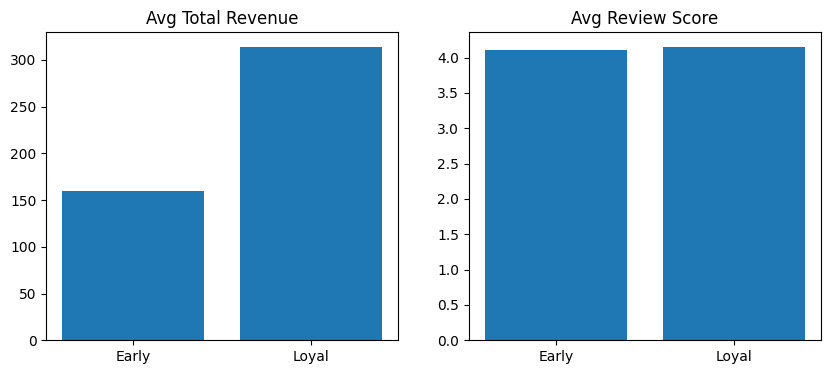

In [30]:
import matplotlib.pyplot as plt

labels = ['Early', 'Loyal']
rev_means = [early_rev.mean(), loyal_rev.mean()]
review_means = [early_review.mean(), loyal_review.mean()]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.bar(labels, rev_means)
plt.title("Avg Total Revenue")

plt.subplot(1,2,2)
plt.bar(labels, review_means)
plt.title("Avg Review Score")

plt.show()

In [43]:
# Value Segment vs Churn
import pandas as pd
from scipy.stats import chi2_contingency

# 교차표
contingency = pd.crosstab(df['value_segment'], df['churn'])

print("📊 Contingency Table")
print(contingency)

# 카이제곱 검정
chi2, p, dof, expected = chi2_contingency(contingency)

print("\n📊 Chi-square Test")
print("chi2:", chi2)
print("p-value:", p)

📊 Contingency Table
churn              0      1
value_segment              
Low             7237  20867
Mid            10089  28099
VIP             8615  21776

📊 Chi-square Test
chi2: 55.58897812808631
p-value: 8.49193716825079e-13


In [31]:
# churn_type → 이진 변수로 변환
df['churn'] = df['churn_type'].apply(lambda x: 0 if x == 'Non-churn' else 1)

print(df['churn'].value_counts())

churn
1    70742
0    25941
Name: count, dtype: int64


In [32]:
# 이탈 고객 vs 유지 고객 평균 차이
from scipy.stats import ttest_ind

# 그룹 분리
churn = df[df['churn'] == 1]
non_churn = df[df['churn'] == 0]

# 결측 제거
churn_rev = churn['total_revenue'].dropna()
non_rev = non_churn['total_revenue'].dropna()

churn_review = churn['review_score'].dropna()
non_review = non_churn['review_score'].dropna()

# t-test
t_rev, p_rev = ttest_ind(churn_rev, non_rev, equal_var=False)
t_review, p_review = ttest_ind(churn_review, non_review, equal_var=False)

print("📊 [Total Revenue]")
print("t-stat:", t_rev)
print("p-value:", p_rev)

print("\n📊 [Review Score]")
print("t-stat:", t_review)
print("p-value:", p_review)

# 평균 출력 (해석용)
print("\n📌 평균 비교")
print("Revenue - churn:", churn_rev.mean(), "| non-churn:", non_rev.mean())
print("Review  - churn:", churn_review.mean(), "| non-churn:", non_review.mean())

📊 [Total Revenue]
t-stat: -7.19791899695017
p-value: 6.220722850367076e-13

📊 [Review Score]
t-stat: -20.30997918848204
p-value: 2.4338976795914932e-91

📌 평균 비교
Revenue - churn: 168.20815456014816 | non-churn: 181.82157218314637
Review  - churn: 4.103748012058203 | non-churn: 4.284953318095533


In [33]:
# 배송지연 vs churn
import pandas as pd
from scipy.stats import chi2_contingency

# 교차표
ct = pd.crosstab(df['is_delayed'], df['churn'])
print("\n📊 Contingency Table")
print(ct)

# 카이제곱 검정
chi2, p, dof, expected = chi2_contingency(ct)

print("\n📊 Chi-square Test")
print("chi2:", chi2)
print("p-value:", p)


📊 Contingency Table
churn           0      1
is_delayed              
0           24316  64541
1            1625   6201

📊 Chi-square Test
chi2: 159.31176721195828
p-value: 1.59963492101917e-36


In [45]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# -------------------------
# 1. 변수 선택
# -------------------------
X = df[['total_revenue', 'review_score', 'is_delayed']].copy()
y = df['churn'].copy()

# -------------------------
# 2. 타입 변환 (🔥 핵심)
# -------------------------
X = X.astype(float)
y = y.astype(float)

# -------------------------
# 3. 결측 제거
# -------------------------
data = pd.concat([X, y], axis=1).dropna()

X = data.drop('churn', axis=1)
y = data['churn']

# -------------------------
# 4. 상수 추가
# -------------------------
X = sm.add_constant(X)

# -------------------------
# 5. 모델 학습
# -------------------------
model = sm.Logit(y, X).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.579489
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                  churn   No. Observations:                96028
Model:                          Logit   Df Residuals:                    96024
Method:                           MLE   Df Model:                            3
Date:                Mon, 08 Jun 2026   Pseudo R-squ.:                0.004431
Time:                        11:00:09   Log-Likelihood:                -55647.
converged:                       True   LL-Null:                       -55895.
Covariance Type:            nonrobust   LLR p-value:                4.855e-107
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             1.4674      0.029     49.759      0.000       1.410       1.525
total_revenue    -0.